In [1]:
# Data Handling
import pandas as pd
import numpy as np

#Visualization 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from PIL import Image
from IPython.display import display
import io
%matplotlib inline

# NLP Preprocessing
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Feature Extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# Model Training & Evaluation
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Label Encoding
from sklearn.preprocessing import LabelEncoder

# Save/Load Model
import joblib

# Streamlit App (for later)
import streamlit as st

## 1) LOADING DATA

In [2]:
Data1 = pd.read_csv("Ai.csv")

In [3]:
Data2 = pd.read_csv("Excersise.csv")

In [4]:
Data3 = pd.read_csv("youtube_videos_full_dataset2.csv")

In [5]:
Data1.info()
Data2.info()
Data3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3770 entries, 0 to 3769
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   video_id                3770 non-null   object
 1   title                   3770 non-null   object
 2   description             2378 non-null   object
 3   published_at            3770 non-null   object
 4   channel_id              3770 non-null   object
 5   channel_title           3770 non-null   object
 6   tags                    3770 non-null   object
 7   tags_count              3770 non-null   int64 
 8   category_id             3770 non-null   int64 
 9   default_language        935 non-null    object
 10  default_audio_language  2253 non-null   object
 11  views                   3770 non-null   int64 
 12  likes                   3770 non-null   int64 
 13  comments                3770 non-null   int64 
 14  duration                3770 non-null   object
 15  defi

### Merging the data

Merging the data since they all have same type of data

In [6]:
Full_data = pd.concat([Data1,Data2,Data3],ignore_index=True)

In [7]:
Full_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9912 entries, 0 to 9911
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   video_id                9912 non-null   object
 1   title                   9912 non-null   object
 2   description             6619 non-null   object
 3   published_at            9912 non-null   object
 4   channel_id              9912 non-null   object
 5   channel_title           9912 non-null   object
 6   tags                    9912 non-null   object
 7   tags_count              9912 non-null   int64 
 8   category_id             9912 non-null   int64 
 9   default_language        5603 non-null   object
 10  default_audio_language  7518 non-null   object
 11  views                   9912 non-null   int64 
 12  likes                   9912 non-null   int64 
 13  comments                9912 non-null   int64 
 14  duration                9912 non-null   object
 15  defi

## 2. CLEANING THE DATA

In [8]:
Full_data.isnull().sum()

video_id                     0
title                        0
description               3293
published_at                 0
channel_id                   0
channel_title                0
tags                         0
tags_count                   0
category_id                  0
default_language          4309
default_audio_language    2394
views                        0
likes                        0
comments                     0
duration                     0
definition                   0
caption                      0
licensed_content             0
region_restriction           0
made_for_kids                0
license                      0
live_broadcast_content       0
topic_categories             0
channel_created_at           0
channel_keywords            19
channel_views                0
channel_subscribers          0
channel_total_videos         0
channel_topics               0
dtype: int64

### i) Handling missing values

In [9]:
missing = Full_data.isnull().sum()
missing_percent = (missing / len(Full_data)) * 100
missing_df = pd.DataFrame({"Missing Values": missing, "Percent": missing_percent})
print(missing_df[missing_df["Missing Values"] > 0])


                        Missing Values    Percent
description                       3293  33.222357
default_language                  4309  43.472559
default_audio_language            2394  24.152542
channel_keywords                    19   0.191687


- Dropping the default_language 
- Filling the description with "No description".
- Replacing default_audio_language with "Unknown".
- Replacing channel_keyword with "None".

In [10]:
Full_data.drop(columns=["default_language"], inplace=True)
Full_data['description'] = Full_data['description'].fillna("No description")
Full_data['default_audio_language'] = Full_data['default_audio_language'].fillna("Unknown")
Full_data['channel_keywords'] = Full_data['channel_keywords'].fillna("None")

In [11]:
Full_data.isnull().sum()

video_id                  0
title                     0
description               0
published_at              0
channel_id                0
channel_title             0
tags                      0
tags_count                0
category_id               0
default_audio_language    0
views                     0
likes                     0
comments                  0
duration                  0
definition                0
caption                   0
licensed_content          0
region_restriction        0
made_for_kids             0
license                   0
live_broadcast_content    0
topic_categories          0
channel_created_at        0
channel_keywords          0
channel_views             0
channel_subscribers       0
channel_total_videos      0
channel_topics            0
dtype: int64

### ii) Handling Data Types

In [12]:
# Create a summary table for Full_data
summary = pd.DataFrame({
    "Data Type": Full_data.dtypes,
    "Missing Values": Full_data.isnull().sum(),
    "Unique Values": Full_data.nunique(),
})
print(summary)


                       Data Type  Missing Values  Unique Values
video_id                  object               0           9763
title                     object               0           9679
description               object               0           6356
published_at              object               0           9753
channel_id                object               0           6040
channel_title             object               0           6035
tags                      object               0           4543
tags_count                 int64               0             64
category_id                int64               0             15
default_audio_language    object               0             75
views                      int64               0           9875
likes                      int64               0           8695
comments                   int64               0           3169
duration                  object               0           1853
definition                object        

In [13]:
Full_data["published_at"]

0       2025-08-17T15:26:03Z
1       2024-06-27T17:48:58Z
2       2025-07-24T16:49:51Z
3       2024-06-02T18:44:51Z
4       2025-06-21T20:21:16Z
                ...         
9907    2025-05-03T01:47:27Z
9908    2025-04-12T00:12:25Z
9909    2025-08-14T20:36:23Z
9910    2025-08-02T11:53:27Z
9911    2023-03-17T01:13:20Z
Name: published_at, Length: 9912, dtype: object

- The published_at column is in ISO 8601 format (YYYY-MM-DDTHH:MM:SSZ), and I will use Pandas to parse into a datetime64.

In [14]:
# Convert published_at to datetime (infer format, handle UTC)
Full_data["published_at"] = pd.to_datetime(
    Full_data["published_at"], 
    utc=True,
    errors="coerce"  # invalid parsing becomes NaT
)

# Extract year, month, day
Full_data['published_year'] = Full_data['published_at'].dt.year
Full_data['published_month'] = Full_data['published_at'].dt.month
Full_data['published_day_date'] = Full_data['published_at'].dt.day

# Add month name
Full_data['published_month_name'] = Full_data['published_at'].dt.month_name()

# Add weekday name
Full_data['published_weekday'] = Full_data['published_at'].dt.day_name()

# Adding a formatted date (YYYY-MM-DD)
Full_data['published_date'] = pd.to_datetime(Full_data['published_at'].dt.strftime('%Y-%m-%d'))

# Optional: check first few rows
print(Full_data[['published_at', 'published_date', 'published_year', 'published_month_name', 
                 'published_day_date', 'published_weekday']].head())


               published_at published_date  published_year  \
0 2025-08-17 15:26:03+00:00     2025-08-17            2025   
1 2024-06-27 17:48:58+00:00     2024-06-27            2024   
2 2025-07-24 16:49:51+00:00     2025-07-24            2025   
3 2024-06-02 18:44:51+00:00     2024-06-02            2024   
4 2025-06-21 20:21:16+00:00     2025-06-21            2025   

  published_month_name  published_day_date published_weekday  
0               August                  17            Sunday  
1                 June                  27          Thursday  
2                 July                  24          Thursday  
3                 June                   2            Sunday  
4                 June                  21          Saturday  


Video publish date (published_at):
- Converted from string to datetime, handling fractional seconds.
- Extracted year, month, day, month name, weekday name, and a clean date similar to channel creation date.

In [15]:
Full_data["duration"]

0       PT17M14S
1          PT11S
2         PT1M1S
3          PT16S
4           PT6S
          ...   
9907     PT2M42S
9908       PT24S
9909       PT18S
9910        PT6S
9911       PT21S
Name: duration, Length: 9912, dtype: object

- The duration column is in ISO 8601 duration format (e.g., PT17M14S = 17 minutes 14 seconds, PT11S = 11 seconds)
- These aren’t actual datetimes, so I can't convert them to datetime directly. Instead, the best approach is to convert them to timedelta (Python’s timedelta type) or total seconds, which makes it easy to work with durations numerically.

In [16]:
# Function to parse ISO 8601 duration and convert directly to seconds
def parse_duration_to_seconds(duration):
    hours = re.search(r'(\d+)H', duration)
    minutes = re.search(r'(\d+)M', duration)
    seconds = re.search(r'(\d+)S', duration)
    
    h = int(hours.group(1)) if hours else 0
    m = int(minutes.group(1)) if minutes else 0
    s = int(seconds.group(1)) if seconds else 0
    
    # Total seconds
    return h*3600 + m*60 + s

# Overwrite the original column with numeric seconds
Full_data["duration"] = Full_data["duration"].apply(parse_duration_to_seconds)

# checking first few rows
print(Full_data["duration"].head())


0    1034
1      11
2      61
3      16
4       6
Name: duration, dtype: int64


In [17]:
Full_data["channel_created_at"]

0              2013-01-07T19:08:50Z
1              2013-10-19T19:39:24Z
2       2023-11-27T18:35:43.182682Z
3              2013-10-19T19:39:24Z
4              2017-09-02T11:03:34Z
                   ...             
9907           2018-05-01T05:39:17Z
9908           2012-01-01T21:25:14Z
9909           2009-12-25T03:25:45Z
9910    2024-12-29T20:16:16.475861Z
9911           2015-06-17T14:33:36Z
Name: channel_created_at, Length: 9912, dtype: object

In [18]:
# Convert to datetime, removing fractional seconds on the fly
Full_data['channel_created_at'] = pd.to_datetime(
    Full_data['channel_created_at'].str.replace(r'\.\d+', '', regex=True),
    utc=True,
    errors='coerce'  # ensures any unparseable rows become NaT
)

# Extract year, month, day, month name, weekday, and formatted date
Full_data['channel_year'] = Full_data['channel_created_at'].dt.year
Full_data['channel_month'] = Full_data['channel_created_at'].dt.month
Full_data['channel_day_date'] = Full_data['channel_created_at'].dt.day
Full_data['channel_month_name'] = Full_data['channel_created_at'].dt.month_name()
Full_data['channel_weekday'] = Full_data['channel_created_at'].dt.day_name()
Full_data['channel_date'] = pd.to_datetime(Full_data['channel_created_at'].dt.strftime('%Y-%m-%d'))

# Check first few rows
print(Full_data[['channel_created_at', 'channel_date', 'channel_year', 
                 'channel_month_name', 'channel_day_date', 'channel_weekday']].head())


         channel_created_at channel_date  channel_year channel_month_name  \
0 2013-01-07 19:08:50+00:00   2013-01-07          2013            January   
1 2013-10-19 19:39:24+00:00   2013-10-19          2013            October   
2 2023-11-27 18:35:43+00:00   2023-11-27          2023           November   
3 2013-10-19 19:39:24+00:00   2013-10-19          2013            October   
4 2017-09-02 11:03:34+00:00   2017-09-02          2017          September   

   channel_day_date channel_weekday  
0                 7          Monday  
1                19        Saturday  
2                27          Monday  
3                19        Saturday  
4                 2        Saturday  


Channel creation date (channel_created_at):
- Converted from string to datetime with automatic format inference.
- Extracted year, month, day, month name, weekday name, and a clean date for readability and analysis.

In [19]:
# Convert categorical columns
categorical_cols = [
    "category_id", "definition", "default_audio_language", 
    "region_restriction", "license", "live_broadcast_content","live_broadcast_content"
]
for col in categorical_cols:
    Full_data[col] = Full_data[col].astype("category")

In [20]:
Full_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9912 entries, 0 to 9911
Data columns (total 40 columns):
 #   Column                  Non-Null Count  Dtype              
---  ------                  --------------  -----              
 0   video_id                9912 non-null   object             
 1   title                   9912 non-null   object             
 2   description             9912 non-null   object             
 3   published_at            9912 non-null   datetime64[ns, UTC]
 4   channel_id              9912 non-null   object             
 5   channel_title           9912 non-null   object             
 6   tags                    9912 non-null   object             
 7   tags_count              9912 non-null   int64              
 8   category_id             9912 non-null   category           
 9   default_audio_language  9912 non-null   category           
 10  views                   9912 non-null   int64              
 11  likes                   9912 non-null   int

## 3. ANALYSIS

## 3.1.Descriptive Analysis (Summary Statistics & Exploration)

## A) Video-level metrics

#### i) Views, likes, comments, duration

In [21]:
#)Mean, median, max, min, std
video_metrics = ['views', 'likes', 'comments', 'duration']
summary_stats = Full_data[video_metrics].describe().T
summary_stats['median'] = Full_data[video_metrics].median()
summary_stats


,count,mean,std,min,25%,50%,75%,max,median
views,9912.0,1.081788e+07,4.485582e+07,0.0,222795.5,1383458.5,6463069.50,1.888745e+09,1383458.5
likes,9912.0,2.207907e+05,7.622276e+05,0.0,3648.5,26027.0,147156.75,1.955550e+07,26027.0
comments,9912.0,2.149768e+03,1.356458e+04,0.0,65.0,309.0,1245.00,9.794140e+05,309.0
duration,9912.0,4.925967e+02,1.682378e+03,0.0,22.0,51.0,239.00,4.290000e+04,51.0


- Views, likes, and comments are heavily right-skewed, with a small number of viral videos driving the mean.
- edian values are much lower than the mean for all engagement metrics
- Video durations vary widely; most videos are short, but there are some extreme outliers.

#### ii) ploting the distribution

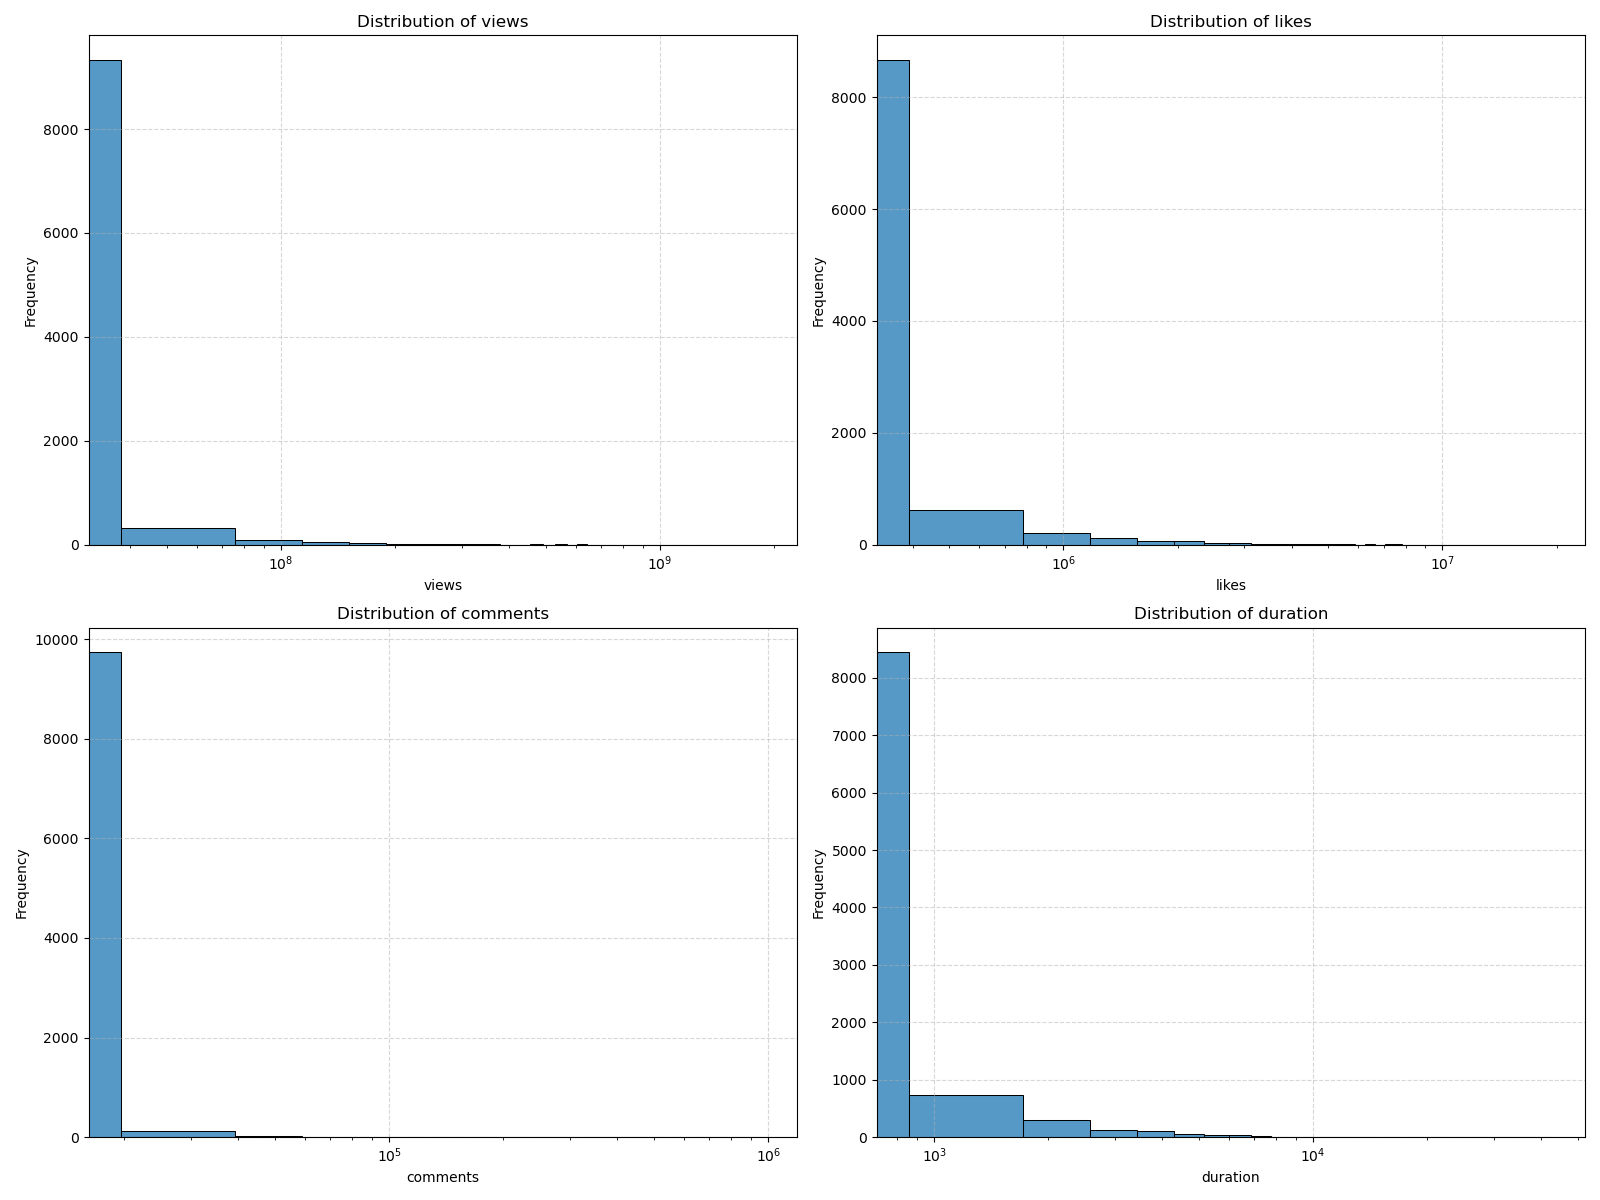

In [22]:
metrics = ['views', 'likes', 'comments', 'duration']

# Creating the figure
plt.figure(figsize=(16,12))
for i, col in enumerate(metrics, 1):
    plt.subplot(2, 2, i)
    sns.histplot(Full_data[col], bins=50, kde=False)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.xscale('log')  # log scale for skewed data
    plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()

buf = io.BytesIO()
plt.savefig(buf, format='png')  
buf.seek(0)
img = Image.open(buf)
display(img)
buf.close()
plt.close() 

- Highly skewed distributions: views, likes, comments, and duration all have long right tails.
- Median << mean: typical videos get far fewer views/likes/comments than the average suggests.
- Log scale is crucial: without it, almost all low-value data would be invisible.
- Engagement correlation: videos with more views generally get more likes and comments.
- Duration outliers: a few very long videos heavily influence average duration.

### iii) Correlation Between Views, Likes, Comments

             views     likes  comments
views     1.000000  0.778121  0.525904
likes     0.778121  1.000000  0.398242
comments  0.525904  0.398242  1.000000


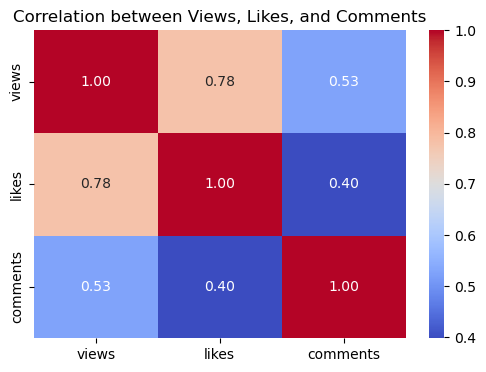

In [23]:
# Correlation matrix
corr_matrix = Full_data[['views', 'likes', 'comments']].corr()
print(corr_matrix)

# Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation between Views, Likes, and Comments')
plt.show()


- Views drive engagement: Both likes and comments rise with views.
- Likes are more strongly tied to views than comments are.liking is easier than commenting.
- Comments are more independent: A video can have lots of likes but relatively few comments (e.g., music videos), or lots of comments without as many likes (e.g., controversial topics).
- No negative correlations: All metrics move in the same direction.
-------
- Views are the main driver.
- Likes are a better engagement predictor than comments.
- Comments add unique information beyond views and likes.

## B)Tags & categories

### i) Count of tags per video

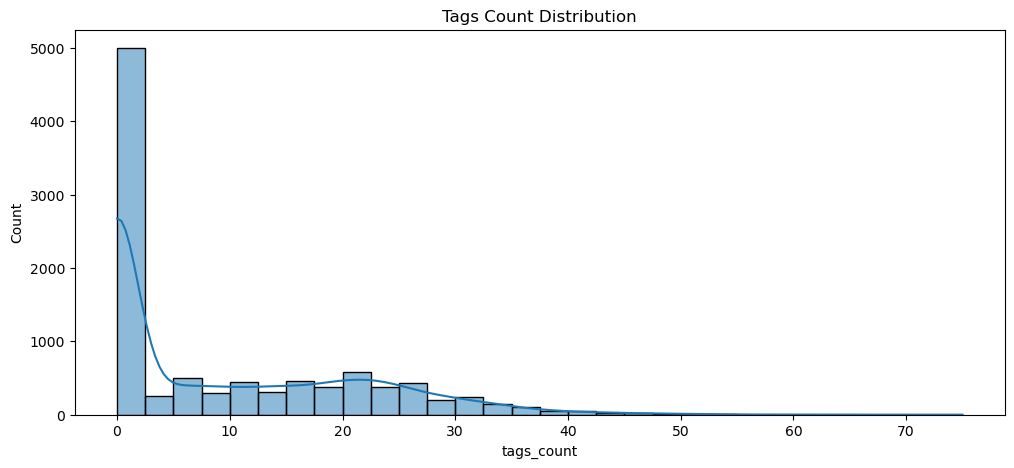

In [24]:
# Tags count distribution
plt.figure(figsize=(12,5))
sns.histplot(Full_data['tags_count'], bins=30, kde=True)
plt.title('Tags Count Distribution')
plt.show()

- Many videos have very few or no tags.
- Few videos have a very high number of tags (30–70+), but they are rare.
- More than half of the videos have fewer than 5 tags.
- While the majority use few tags, there is still a spread of videos with 5–20 tags.d

### ii) Most common tags

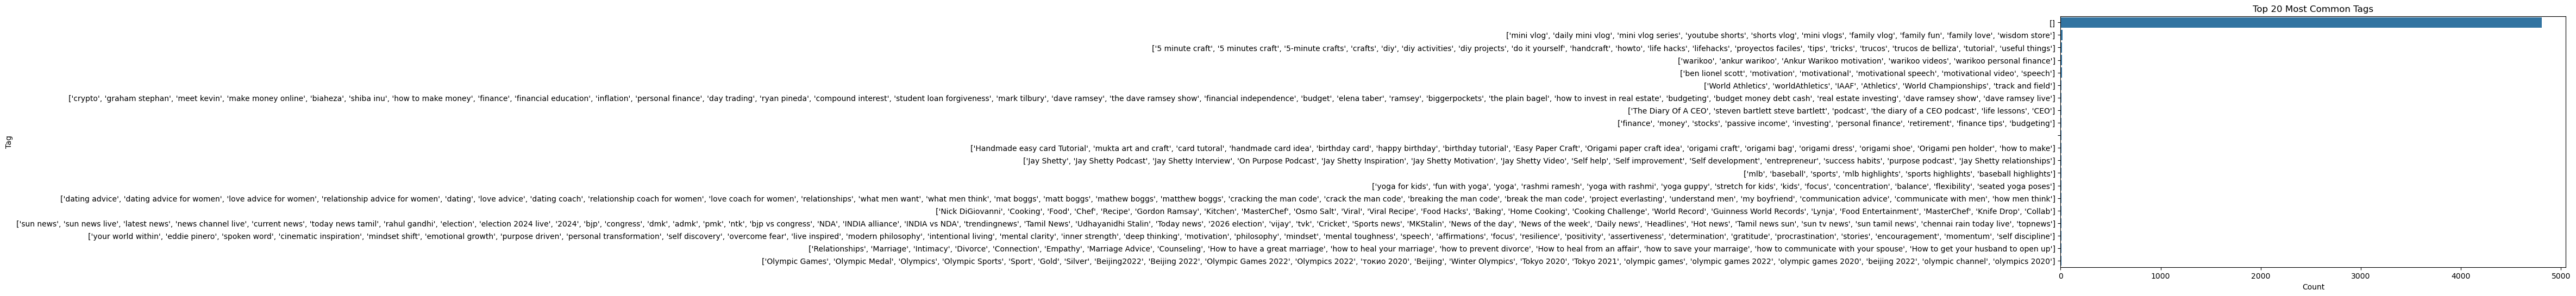

In [25]:
from collections import Counter

# Flatten all tags
all_tags = []
Full_data['tags'].str.split('|').dropna().apply(all_tags.extend)

# Count most common tags
tag_counts = Counter(all_tags).most_common(20)

# Convert to DataFrame for plotting
tag_df = pd.DataFrame(tag_counts, columns=['Tag', 'Count'])

plt.figure(figsize=(12,6))
sns.barplot(x='Count', y='Tag', data=tag_df)
plt.title("Top 20 Most Common Tags")
plt.show()


### iii) Distribution Across Categorical Features

In [26]:
category_mapping = {
    1: "Film & Animation",
    2: "Autos & Vehicles",
    10: "Music",
    15: "Pets & Animals",
    17: "Sports",
    19: "Travel & Events",
    20: "Gaming",
    22: "People & Blogs",
    23: "Comedy",
    24: "Entertainment",
    25: "News & Politics",
    26: "How-to & Style",
    27: "Education",
    28: "Science & Technology",
    29: "Nonprofits & Activism"
}

Full_data['category_name'] = Full_data['category_id'].astype(int).map(category_mapping)


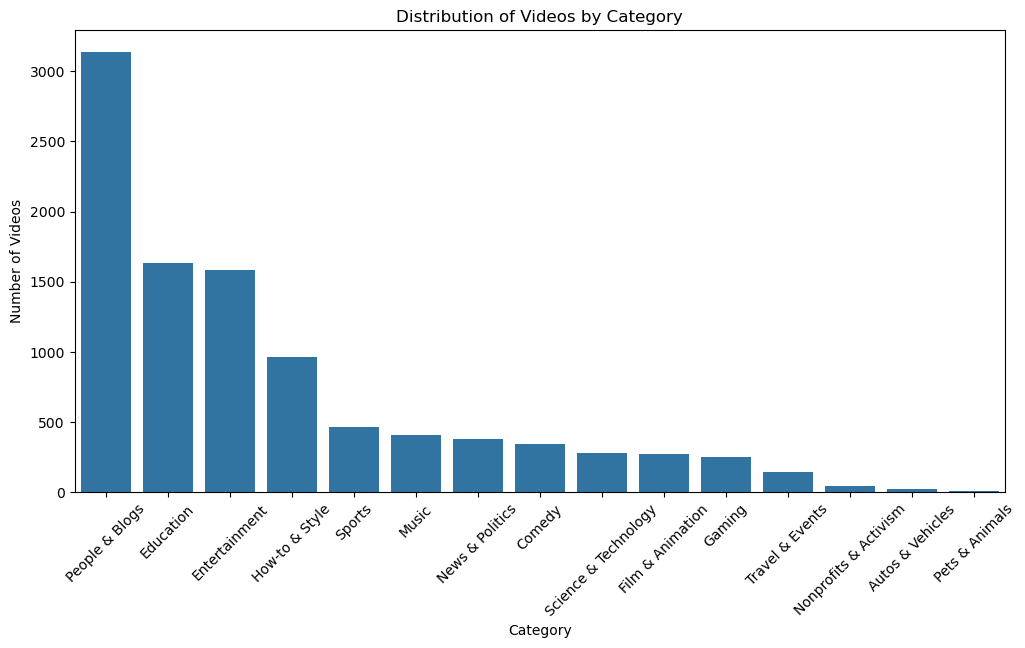

In [27]:
# Plot using category_name 
plt.figure(figsize=(12,6))
sns.countplot(data=Full_data, 
              x='category_name', 
              order=Full_data['category_name'].value_counts().index)

plt.title("Distribution of Videos by Category")
plt.xlabel("Category")
plt.ylabel("Number of Videos")
plt.xticks(rotation=45) 
plt.show()


### iv) Engagement Ratios

In [28]:
# Avoid division by zero
Full_data["view_rate"] = Full_data["views"] / Full_data["channel_subscribers"].replace(0, 1)
# Create engagement ratios
Full_data["like_rate"] = Full_data["likes"] / Full_data["views"].replace(0, 1)
Full_data["comment_rate"] = Full_data["comments"] / Full_data["views"].replace(0, 1)

# Group by category
engagement_ratio = (
    Full_data.groupby("category_name")[["like_rate", "comment_rate", "view_rate"]]
    .mean()
    .sort_values("view_rate", ascending=False)
    .round(4)
)

print(engagement_ratio)


                       like_rate  comment_rate  view_rate
category_name                                            
Music                     0.0204        0.0014   434.8100
People & Blogs            0.0303        0.0011    76.5532
Film & Animation          0.0190        0.0006    51.9788
Gaming                    0.0341        0.0017    50.1320
Autos & Vehicles          0.0292        0.0022    43.0372
Comedy                    0.0347        0.0006    41.9005
Entertainment             0.0292        0.0012    38.8373
Sports                    0.0236        0.0004    35.4557
How-to & Style            0.0254        0.0008    35.1248
Science & Technology      0.0323        0.0017    31.1101
Pets & Animals            0.0360        0.0005    22.7754
Education                 0.0352        0.0017    17.6211
Travel & Events           0.0267        0.0011    17.3301
Nonprofits & Activism     0.0284        0.0011    11.4348
News & Politics           0.0202        0.0027     2.3892


### v) Distribution by definition (HD vs SD)

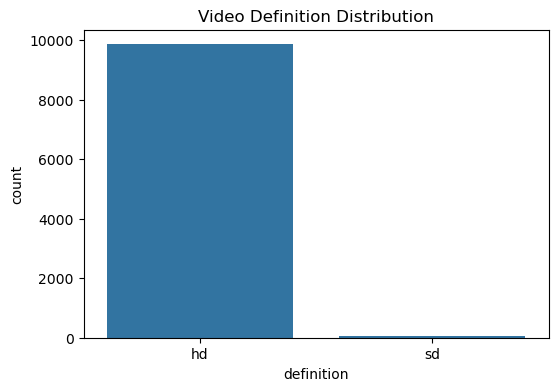

In [29]:
plt.figure(figsize=(6,4))
sns.countplot(data=Full_data, x='definition')
plt.title("Video Definition Distribution")
plt.show()


- hd - High Definition video (e.g., 720p, 1080p, 1440p, 2160p/4K).
- sd - Standard Definition video (typically 240p, 360p, or 480p).

- Most videos produced are in HD format.
- The top 20 Most Common Tags include daily mini volgs,mini vlogs,youtube shorts, family vlogs etc.
- Music is the King of visibility withhighest views, even though like rate is lower.
- People & Blogs is the most uploaded category, but average engagement (oversaturated).
- Comedy, Education, Gaming has strong like rates, but not as many views as Music.
- News & Politics gets fewer views but drives the most discussion (high comment rate).
- Small categories (Pets, Autos, Nonprofits) have few videos, but sometimes high engagement (niche communities).

## C.Publication Patterns

### i) Number of videos published per year

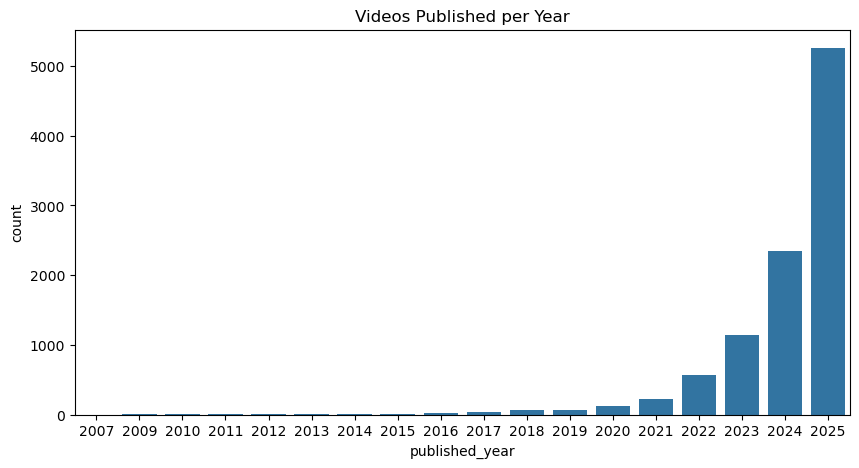

In [30]:
# Videos published per year
plt.figure(figsize=(10,5))
sns.countplot(data=Full_data, x='published_year', order=sorted(Full_data['published_year'].unique()))
plt.title("Videos Published per Year")
plt.show()


### ii)Videos published per month

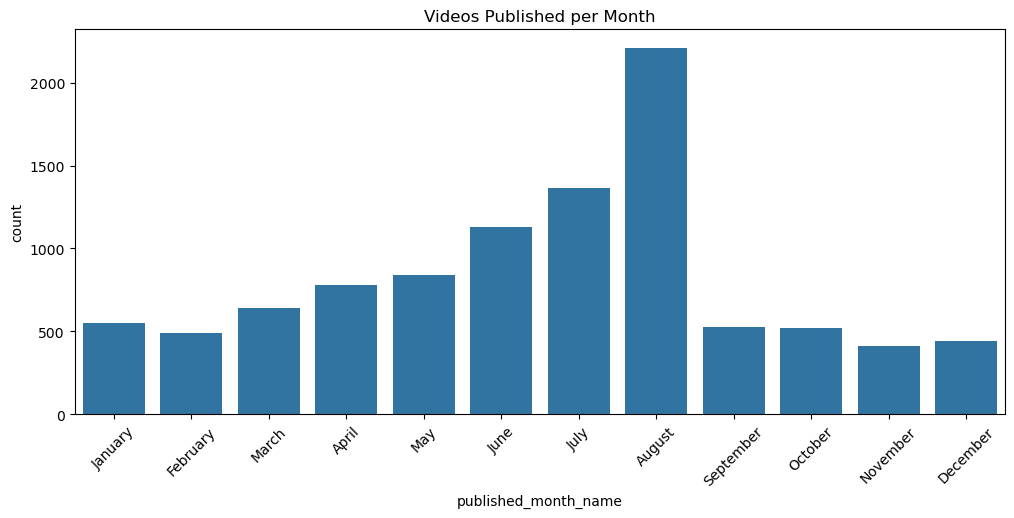

In [31]:
# Videos Published per month
plt.figure(figsize=(12,5))
sns.countplot(data=Full_data, x='published_month_name', order=[
    "January","February","March","April","May","June","July","August","September","October","November","December"])
plt.title("Videos Published per Month")
plt.xticks(rotation=45)
plt.show()


### iii) Videos published per weekday

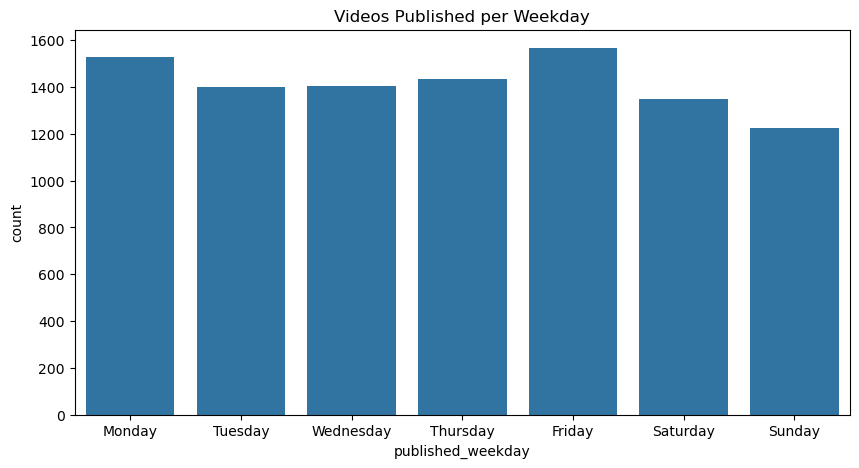

In [32]:
# Videos published per weekday
plt.figure(figsize=(10,5))
sns.countplot(data=Full_data, x='published_weekday',
              order=["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])
plt.title("Videos Published per Weekday")
plt.show()


### iv)Distributions of videos with captions vs licensed and Non-licensed content

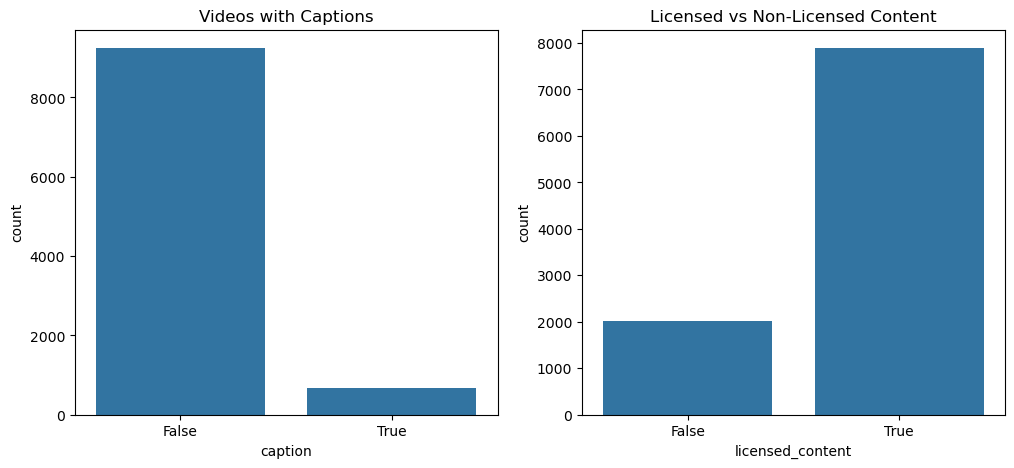

In [33]:
# Videos with captions vs licensed and Non-licensed content
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.countplot(data=Full_data, x='caption', ax=axes[0])
axes[0].set_title("Videos with Captions")

sns.countplot(data=Full_data, x='licensed_content', ax=axes[1])
axes[1].set_title("Licensed vs Non-Licensed Content")

plt.show()


- Publishing trends are weekday-heavy (esp. Fridays, Mondays).
- Most videos lack captions, but most are licensed.
- The dataset shows rapid growth in recent years (2022–2025).
- Seasonal spikes in summer, especially August.
- Publish on Fridays or Mondays for high exposure.
- Experiment with Sundays for less competition.
- Capitalize on summer months (June–August) when engagement is at its highest.
- Add captions to every video → easy way to boost accessibility + SEO.
- Focus on unique, licensed/original content to stay competitive as uploads surge each year.

# 3.2 Content Analysis

## A) Title & description

### i) Word clouds of frequent words

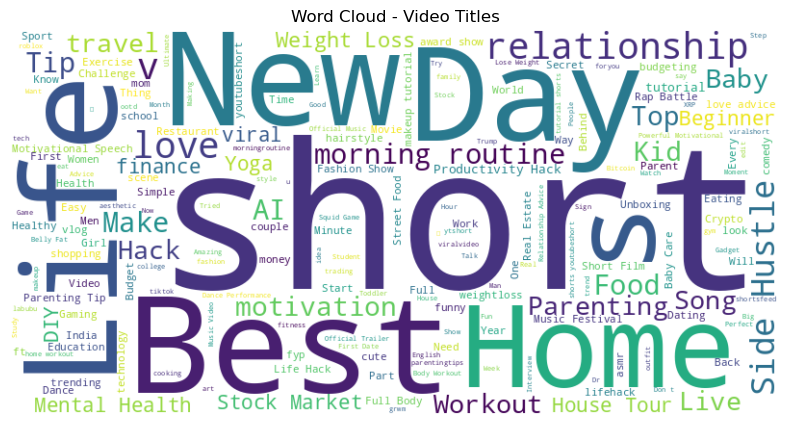

In [34]:
# Word cloud for titles
from wordcloud import WordCloud
text_titles = " ".join(Full_data["title"].dropna())
wc_titles = WordCloud(width=800, height=400, background_color="white").generate(text_titles)

plt.figure(figsize=(10,5))
plt.imshow(wc_titles, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud - Video Titles")
plt.show()


## ii)Sentiment Analysis (Titles & Descriptions)

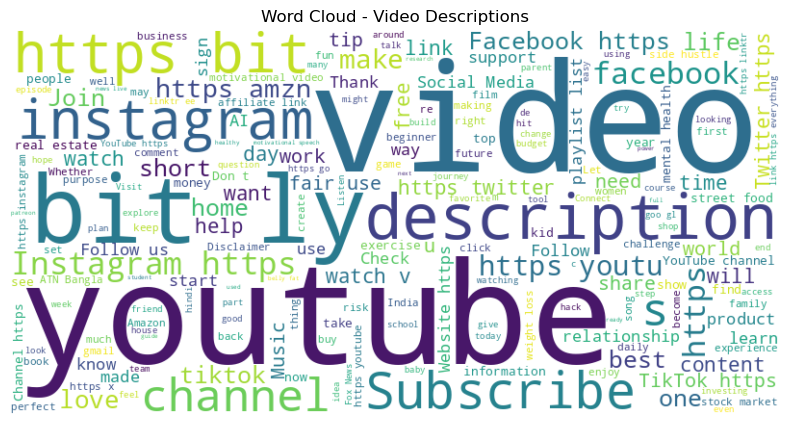

In [35]:
# Description
text_desc = " ".join(Full_data["description"].dropna().astype(str))
wc_desc = WordCloud(width=800, height=400, background_color="white").generate(text_desc)

plt.figure(figsize=(10,5))
plt.imshow(wc_desc, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud - Video Descriptions")
plt.show()

### iii)Sentiment Distribution (Title vs Description)

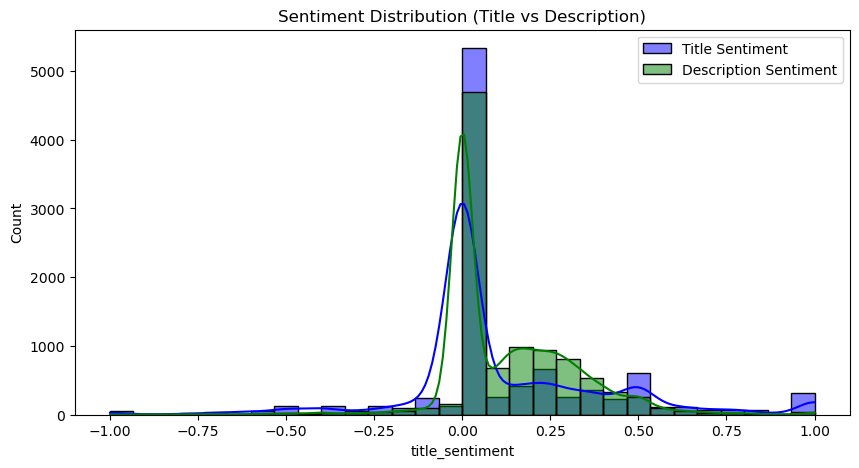

In [37]:
from textblob import TextBlob
Full_data["title_sentiment"] = Full_data["title"].dropna().astype(str).apply(lambda x: TextBlob(x).sentiment.polarity)
Full_data["desc_sentiment"] = Full_data["description"].dropna().astype(str).apply(lambda x: TextBlob(x).sentiment.polarity)

# Plot sentiment distributions
plt.figure(figsize=(10,5))
sns.histplot(Full_data["title_sentiment"], kde=True, bins=30, color="blue", label="Title Sentiment")
sns.histplot(Full_data["desc_sentiment"], kde=True, bins=30, color="green", label="Description Sentiment")
plt.legend()
plt.title("Sentiment Distribution (Title vs Description)")
plt.show()

### iv) Length of Title/Description vs Engagement

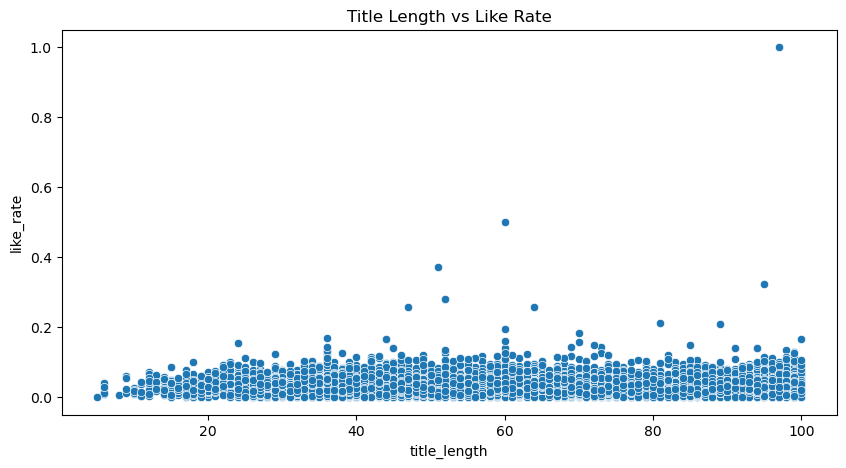

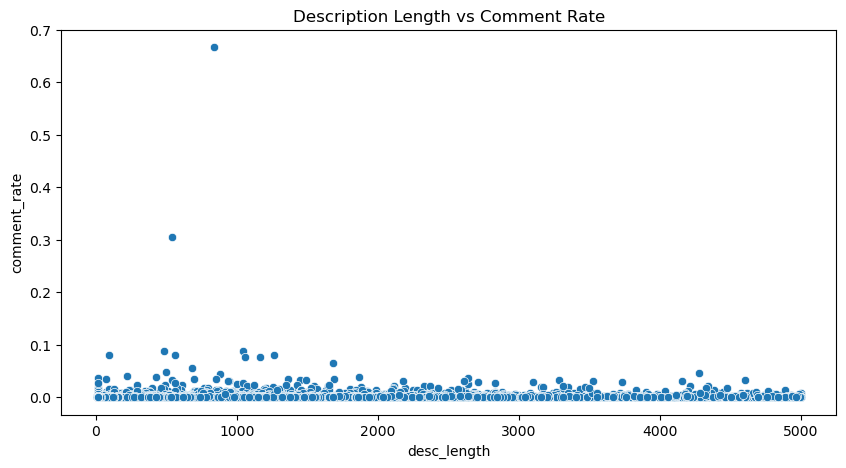

In [38]:
# --- 3. Length of Title/Description vs Engagement
Full_data["title_length"] = Full_data["title"].astype(str).str.len()
Full_data["desc_length"] = Full_data["description"].astype(str).str.len()

plt.figure(figsize=(10,5))
sns.scatterplot(data=Full_data, x="title_length", y="like_rate")
plt.title("Title Length vs Like Rate")
plt.show()

plt.figure(figsize=(10,5))
sns.scatterplot(data=Full_data, x="desc_length", y="comment_rate")
plt.title("Description Length vs Comment Rate")
plt.show()

- Titles emphasize themes (shorts, lifestyle, motivation, relationships, finance, fitness).
- Descriptions are more about links, promotion, and calls to action.
- Sentiment is mostly neutral, but titles show slightly stronger emotional tone than descriptions.
- Title length has little impact on likes. Viral success seems independent of length.
- Description length has little effect on comments, though a few cases show strong engagement.
- Description length does not drive comments; other factors (topic, audience engagement) matter more.
- Creators keep descriptions neutral/professional, while titles sometimes use stronger sentiment (positive/negative) to grab attention.

## B) Tags

### i)Tag Diversity vs Engagement

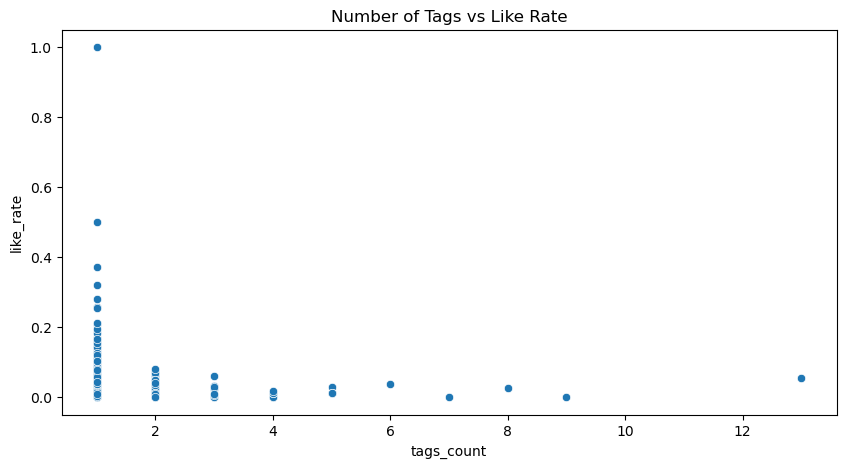

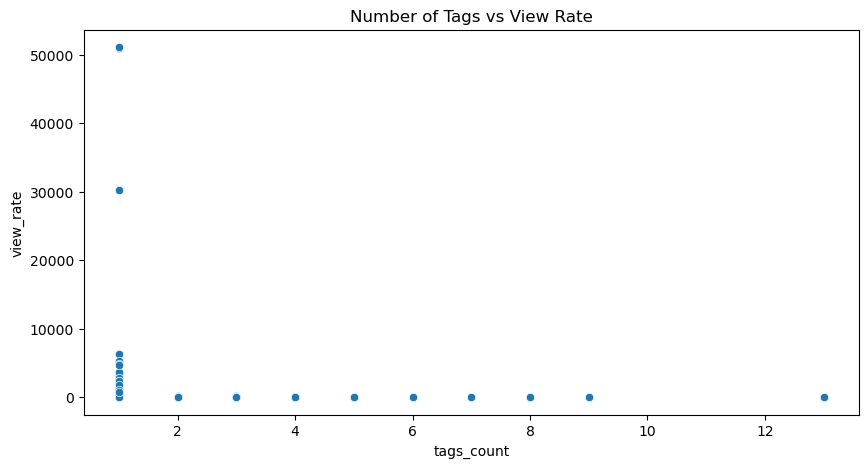

In [39]:
Full_data["tags_count"] = Full_data["tags"].dropna().astype(str).apply(lambda x: len(x.split("|")) if x != "None" else 0)

plt.figure(figsize=(10,5))
sns.scatterplot(data=Full_data, x="tags_count", y="like_rate")
plt.title("Number of Tags vs Like Rate")
plt.show()

plt.figure(figsize=(10,5))
sns.scatterplot(data=Full_data, x="tags_count", y="view_rate")
plt.title("Number of Tags vs View Rate")
plt.show()

In [ ]:
Full_data.to_csv("cleaned_data.csv")